# Classificação de E-mails: Spam ou Não Spam
**Instituto Federal do Piauí - Campus Paulistana**  
**Disciplina:** Inteligência Artificial  
**Professora:** Maíla de Lima Claro  

---
Este notebook demonstra o projeto completo de Machine Learning para classificação de e-mails como Spam ou Não Spam, utilizando três algoritmos: Naive Bayes, Regressão Logística e Random Forest.

## 1. Importação das Bibliotecas

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# Cria as pastas de saída se não existirem
os.makedirs('results/figures', exist_ok=True)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento e Visualização dos Dados

In [4]:
# Garante que o notebook roda sempre a partir da raiz do projeto
import os
os.chdir(r'C:\Users\kayky\Desktop\classificacao_spam')

# Carrega o dataset de e-mails obtido na plataforma Kaggle
df = pd.read_csv('data/raw/emails/emails.csv', encoding='latin-1')

print(f'Total de e-mails carregados: {len(df)}')
print(f'Total de colunas (palavras): {len(df.columns)}')
print()

# Exibe as primeiras linhas do dataset
df.head()

Total de e-mails carregados: 5172
Total de colunas (palavras): 3002



,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


## 3. Pré-processamento dos Dados

In [5]:
# Remove a coluna de identificação, que não contribui para o aprendizado
if 'Email No.' in df.columns:
    df = df.drop('Email No.', axis=1)

# Renomeia a coluna alvo para padronizar o projeto
if 'Prediction' in df.columns:
    df = df.rename(columns={'Prediction': 'label_num'})

# Remove linhas com valores ausentes
df = df.dropna()

# Exibe a distribuição das classes
total = len(df)
spam = df['label_num'].sum()
nao_spam = total - spam

print(f'Total de e-mails após limpeza: {total}')
print(f'Spam:     {spam}  ({spam/total*100:.1f}%)')
print(f'Não Spam: {nao_spam} ({nao_spam/total*100:.1f}%)')

Total de e-mails após limpeza: 5172
Spam:     1500  (29.0%)
Não Spam: 3672 (71.0%)


## 4. Divisão em Dados de Treino e Teste

In [6]:
# Separa as features (X) do alvo (y)
X = df.drop('label_num', axis=1)
y = df['label_num']

# Divisão 80% treino e 20% teste, com semente fixa para reprodutibilidade
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'E-mails para treinar os modelos: {len(X_treino)}')
print(f'E-mails para testar os modelos:  {len(X_teste)}')

E-mails para treinar os modelos: 4137
E-mails para testar os modelos:  1035


## 5. Treinamento dos Modelos

In [7]:
# Naive Bayes — modelo probabilístico simples e eficiente para texto
modelo_nb = MultinomialNB()
modelo_nb.fit(X_treino, y_treino)
print('✓ Naive Bayes treinado')

# Regressão Logística — boa para classificação binária
modelo_lr = LogisticRegression(max_iter=1000)  # max_iter evita erro de convergência
modelo_lr.fit(X_treino, y_treino)
print('✓ Regressão Logística treinada')

# Random Forest — conjunto de 100 árvores de decisão
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_treino, y_treino)
print('✓ Random Forest treinado')

✓ Naive Bayes treinado
✓ Regressão Logística treinada
✓ Random Forest treinado


## 6. Avaliação dos Modelos

In [8]:
# Gera as previsões de cada modelo sobre os dados de teste
prev_nb = modelo_nb.predict(X_teste)
prev_lr = modelo_lr.predict(X_teste)
prev_rf = modelo_rf.predict(X_teste)

# Função para calcular e exibir as métricas de classificação
def avaliar_modelo(nome, y_real, y_prev):
    acc  = accuracy_score(y_real, y_prev)
    prec = precision_score(y_real, y_prev)
    rec  = recall_score(y_real, y_prev)
    f1   = f1_score(y_real, y_prev)
    print(f'\n=== {nome} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    return [acc, prec, rec, f1]

metricas_nb = avaliar_modelo('Naive Bayes', y_teste, prev_nb)
metricas_lr = avaliar_modelo('Regressão Logística', y_teste, prev_lr)
metricas_rf = avaliar_modelo('Random Forest', y_teste, prev_rf)


=== Naive Bayes ===
Accuracy:  0.9546
Precision: 0.8903
Recall:    0.9595
F1-Score:  0.9236

=== Regressão Logística ===
Accuracy:  0.9720
Precision: 0.9435
Recall:    0.9595
F1-Score:  0.9514

=== Random Forest ===
Accuracy:  0.9778
Precision: 0.9596
Recall:    0.9628
F1-Score:  0.9612


## 7. Tabela Comparativa de Resultados

In [9]:
# Monta uma tabela organizada com todas as métricas
resultados = pd.DataFrame({
    'Modelo':    ['Naive Bayes', 'Regressão Logística', 'Random Forest'],
    'Accuracy':  [metricas_nb[0], metricas_lr[0], metricas_rf[0]],
    'Precision': [metricas_nb[1], metricas_lr[1], metricas_rf[1]],
    'Recall':    [metricas_nb[2], metricas_lr[2], metricas_rf[2]],
    'F1-Score':  [metricas_nb[3], metricas_lr[3], metricas_rf[3]],
})

resultados.set_index('Modelo', inplace=True)
resultados.round(4)

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Naive Bayes,0.9546,0.8903,0.9595,0.9236
Regressão Logística,0.9720,0.9435,0.9595,0.9514
Random Forest,0.9778,0.9596,0.9628,0.9612


## 8. Matrizes de Confusão

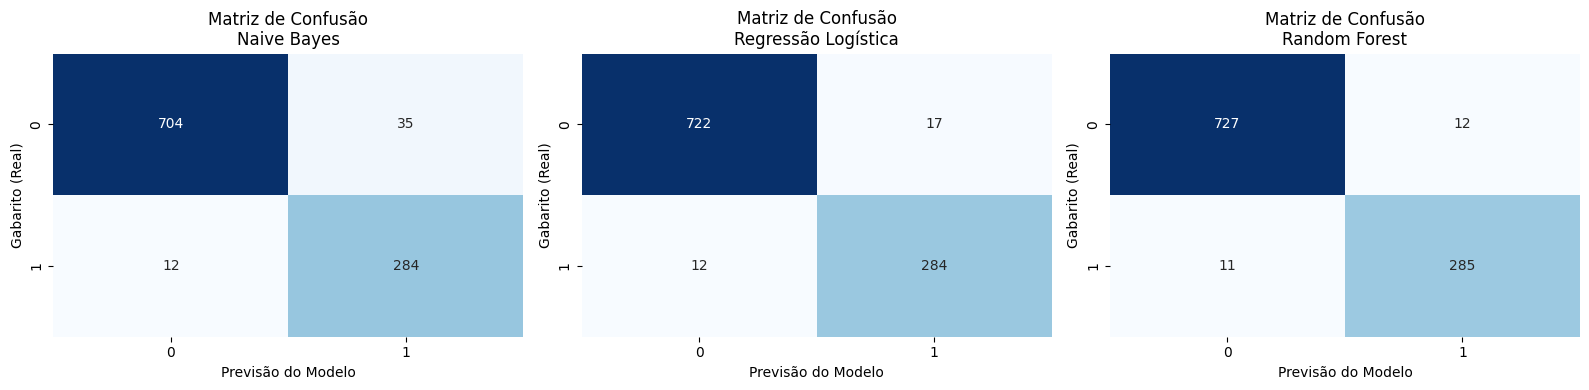

✓ Matrizes de confusão salvas


In [10]:
# Gera as três matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

modelos_plot = [
    ('Naive Bayes', prev_nb),
    ('Regressão Logística', prev_lr),
    ('Random Forest', prev_rf)
]

for ax, (nome, prev) in zip(axes, modelos_plot):
    cm = confusion_matrix(y_teste, prev)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Matriz de Confusão\n{nome}')
    ax.set_ylabel('Gabarito (Real)')
    ax.set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.savefig('results/figures/matrizes_confusao.png')
plt.show()
print('✓ Matrizes de confusão salvas')

## 9. Gráfico Comparativo entre Modelos

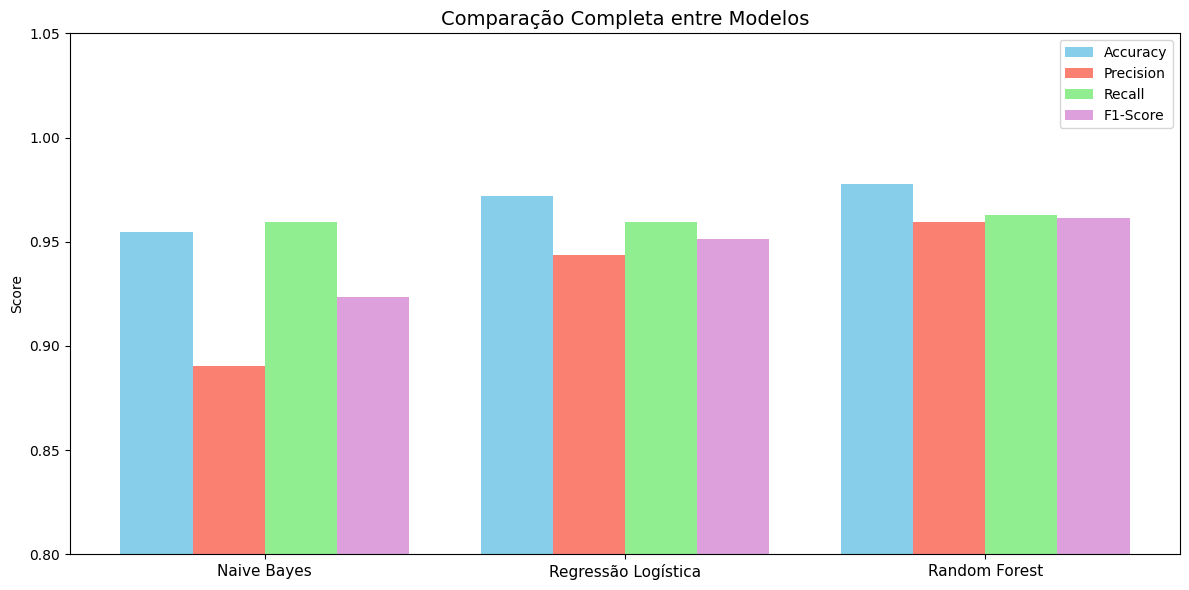

✓ Gráfico comparativo salvo


In [11]:
# Gráfico com todas as métricas para os três modelos
modelos_nomes = ['Naive Bayes', 'Regressão Logística', 'Random Forest']
metricas_dict = {
    'Accuracy':  [metricas_nb[0], metricas_lr[0], metricas_rf[0]],
    'Precision': [metricas_nb[1], metricas_lr[1], metricas_rf[1]],
    'Recall':    [metricas_nb[2], metricas_lr[2], metricas_rf[2]],
    'F1-Score':  [metricas_nb[3], metricas_lr[3], metricas_rf[3]],
}

x = np.arange(len(modelos_nomes))
width = 0.2
cores = ['skyblue', 'salmon', 'lightgreen', 'plum']

plt.figure(figsize=(12, 6))
for i, (metrica, valores) in enumerate(metricas_dict.items()):
    plt.bar(x + i * width, valores, width, label=metrica, color=cores[i])

plt.xticks(x + width * 1.5, modelos_nomes, fontsize=11)
plt.ylim(0.8, 1.05)
plt.title('Comparação Completa entre Modelos', fontsize=14)
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/comparativo_modelos.png')
plt.show()
print('✓ Gráfico comparativo salvo')

## 10. Teste de Classificação Manual

In [12]:
# Simula a classificação de e-mails reais da base de teste
indices = [0, 10, 42, 100, 250]

print('Demonstração de classificação com o modelo Random Forest:\n')
print(f'{"Índice":<8} {"Previsão":<20} {"Real":<20} {"Resultado"}')
print('-' * 60)

for idx in indices:
    if idx >= len(X_teste):
        continue
    
    amostra = X_teste.iloc[[idx]]
    real = y_teste.iloc[idx]
    prev = modelo_rf.predict(amostra)[0]
    
    label_prev = 'SPAM' if prev == 1 else 'NÃO SPAM'
    label_real = 'SPAM' if real == 1 else 'NÃO SPAM'
    resultado  = '✓ ACERTO' if prev == real else '✗ ERRO'
    
    print(f'{idx:<8} {label_prev:<20} {label_real:<20} {resultado}')

Demonstração de classificação com o modelo Random Forest:

Índice   Previsão             Real                 Resultado
------------------------------------------------------------
0        NÃO SPAM             NÃO SPAM             ✓ ACERTO
10       SPAM                 SPAM                 ✓ ACERTO
42       SPAM                 SPAM                 ✓ ACERTO
100      NÃO SPAM             NÃO SPAM             ✓ ACERTO
250      NÃO SPAM             NÃO SPAM             ✓ ACERTO


## 11. Conclusão

Os três modelos treinados apresentaram desempenho elevado na classificação de e-mails. O **Random Forest** obteve os melhores resultados em todas as métricas, seguido pela **Regressão Logística** e pelo **Naive Bayes**.

| Modelo | Ponto Forte | Limitação |
|---|---|---|
| Naive Bayes | Rápido e simples | Precisão mais baixa |
| Regressão Logística | Bom equilíbrio geral | Requer mais tempo de treino |
| Random Forest | Melhor desempenho geral | Modelo mais pesado |

**Possíveis melhorias:** aplicar técnicas de balanceamento de classes, testar outros algoritmos como SVM ou XGBoost, e realizar ajuste fino de hiperparâmetros com Grid Search.